# Проверка устойчивости гипотезы по регионам Северо-Кавказского ФО

Цель ноутбука:
- для каждого региона Северо-Кавказского федерального округа проверить тестом Левене нулевую гипотезу о равенстве дисперсий зарплатных ожиданий у мобильных и немобильных соискателей;
- для каждого региона проверить односторонним двухвыборочным t-критерием Уэльча гипотезу:

**"мобильные соискатели в среднем имеют более высокие зарплатные ожидания, чем не мобильные"**.

Мобильными считаются соискатели, для которых выполнено хотя бы одно из условий:
- `business_trips == 1`;
- `relocation == 1`;
- `schedule_type_1 == 1`.


In [1]:
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)
sns.set_theme(style="whitegrid")

## 1. Загрузка данных и выделение Северо-Кавказского ФО

In [2]:
df = pd.read_csv("dataset_cleaned.csv")

for col in ["salary", "business_trips", "relocation", "schedule_type_1"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["is_mobile"] = (
    df["business_trips"].eq(1)
    | df["relocation"].eq(1)
    | df["schedule_type_1"].eq(1)
)

skfo = df[df["federal_district"] == "Северо-Кавказский"].copy()

print("Размер выборки Северо-Кавказского ФО:", skfo.shape)
print("Регионы в данных:")
print(skfo["region_name"].value_counts().to_string())

Размер выборки Северо-Кавказского ФО: (1678, 67)
Регионы в данных:
region_name
Чеченская Республика        938
Ставропольский край         441
Северная Осетия — Алания    299


## 2. Размеры групп по регионам

Этот шаг нужен, чтобы убедиться, что в каждом регионе есть обе сравниваемые группы.

In [3]:
group_sizes = (
    skfo.groupby(["region_name", "is_mobile"])["salary"]
    .count()
    .unstack(fill_value=0)
    .rename(columns={False: "n_non_mobile", True: "n_mobile"})
    [["n_mobile", "n_non_mobile"]]
    .sort_index()
)

group_sizes

is_mobile,n_mobile,n_non_mobile
region_name,,
Северная Осетия — Алания,7,292
Ставропольский край,48,393
Чеченская Республика,107,831


## 3. Функции для тестов

В текущем окружении нет `scipy`, поэтому тест Левене, распределение Фишера и распределение Стьюдента считаются вручную.

In [4]:
def betacf(a, b, x, max_iter=200, eps=3e-14):
    qab = a + b
    qap = a + 1.0
    qam = a - 1.0
    c = 1.0
    d = 1.0 - qab * x / qap
    if abs(d) < 1e-300:
        d = 1e-300
    d = 1.0 / d
    h = d

    for m in range(1, max_iter + 1):
        m2 = 2 * m

        aa = m * (b - m) * x / ((qam + m2) * (a + m2))
        d = 1.0 + aa * d
        if abs(d) < 1e-300:
            d = 1e-300
        c = 1.0 + aa / c
        if abs(c) < 1e-300:
            c = 1e-300
        d = 1.0 / d
        h *= d * c

        aa = -(a + m) * (qab + m) * x / ((a + m2) * (qap + m2))
        d = 1.0 + aa * d
        if abs(d) < 1e-300:
            d = 1e-300
        c = 1.0 + aa / c
        if abs(c) < 1e-300:
            c = 1e-300
        d = 1.0 / d
        delta = d * c
        h *= delta

        if abs(delta - 1.0) < eps:
            break

    return h


def regularized_incomplete_beta(a, b, x):
    if x <= 0.0:
        return 0.0
    if x >= 1.0:
        return 1.0

    ln_beta = math.lgamma(a) + math.lgamma(b) - math.lgamma(a + b)
    bt = math.exp(a * math.log(x) + b * math.log(1.0 - x) - ln_beta)

    if x < (a + 1.0) / (a + b + 2.0):
        return bt * betacf(a, b, x) / a

    return 1.0 - bt * betacf(b, a, 1.0 - x) / b


def f_cdf(x, d1, d2):
    if x <= 0:
        return 0.0
    z = (d1 * x) / (d1 * x + d2)
    return regularized_incomplete_beta(d1 / 2.0, d2 / 2.0, z)


def student_t_cdf(t, nu):
    if t == 0:
        return 0.5

    x = nu / (nu + t * t)
    ib = regularized_incomplete_beta(nu / 2.0, 0.5, x)

    if t > 0:
        return 1.0 - 0.5 * ib

    return 0.5 * ib


def levene_test_mean(sample_a, sample_b):
    groups = [pd.Series(sample_a).dropna().astype(float), pd.Series(sample_b).dropna().astype(float)]
    k = len(groups)
    ni = [len(group) for group in groups]
    N = sum(ni)

    deviations = [abs(group - group.mean()) for group in groups]
    dev_means = [dev.mean() for dev in deviations]
    grand_mean = sum(n * m for n, m in zip(ni, dev_means)) / N

    ss_between = sum(n * (m - grand_mean) ** 2 for n, m in zip(ni, dev_means))
    ss_within = sum(((dev - m) ** 2).sum() for dev, m in zip(deviations, dev_means))

    df1 = k - 1
    df2 = N - k
    statistic = (ss_between / df1) / (ss_within / df2)
    p_value = 1.0 - f_cdf(statistic, df1, df2)

    return statistic, df1, df2, p_value


def welch_ttest_greater(sample_mobile, sample_non_mobile):
    sample_mobile = pd.Series(sample_mobile).dropna().astype(float)
    sample_non_mobile = pd.Series(sample_non_mobile).dropna().astype(float)

    n_mobile = sample_mobile.shape[0]
    n_non_mobile = sample_non_mobile.shape[0]
    mean_mobile = sample_mobile.mean()
    mean_non_mobile = sample_non_mobile.mean()
    var_mobile = sample_mobile.var(ddof=1)
    var_non_mobile = sample_non_mobile.var(ddof=1)

    se = math.sqrt(var_mobile / n_mobile + var_non_mobile / n_non_mobile)
    t_stat = (mean_mobile - mean_non_mobile) / se
    df_welch = (var_mobile / n_mobile + var_non_mobile / n_non_mobile) ** 2 / (
        ((var_mobile / n_mobile) ** 2) / (n_mobile - 1) + ((var_non_mobile / n_non_mobile) ** 2) / (n_non_mobile - 1)
    )
    p_value = 1.0 - student_t_cdf(t_stat, df_welch)

    return t_stat, df_welch, p_value

## 4. Проверка гипотез по каждому региону

In [5]:
alpha = 0.05
rows = []

for region, sub_df in skfo.groupby("region_name"):
    mobile = sub_df.loc[sub_df["is_mobile"], "salary"].dropna().astype(float)
    non_mobile = sub_df.loc[~sub_df["is_mobile"], "salary"].dropna().astype(float)

    levene_stat, levene_df1, levene_df2, levene_p = levene_test_mean(mobile, non_mobile)
    welch_t, welch_df, welch_p = welch_ttest_greater(mobile, non_mobile)

    rows.append({
        "region_name": region,
        "n_mobile": len(mobile),
        "n_non_mobile": len(non_mobile),
        "mean_mobile": mobile.mean(),
        "mean_non_mobile": non_mobile.mean(),
        "variance_mobile": mobile.var(ddof=1),
        "variance_non_mobile": non_mobile.var(ddof=1),
        "levene_stat": levene_stat,
        "levene_p": levene_p,
        "levene_reject_h0": levene_p < alpha,
        "welch_t": welch_t,
        "welch_df": welch_df,
        "welch_p_greater": welch_p,
        "welch_supports_h1": welch_p < alpha,
    })

results = pd.DataFrame(rows).sort_values("region_name").reset_index(drop=True)
results.round(6)

,region_name,n_mobile,n_non_mobile,mean_mobile,mean_non_mobile,variance_mobile,variance_non_mobile,levene_stat,levene_p,levene_reject_h0,welch_t,welch_df,welch_p_greater,welch_supports_h1
0,Северная Осетия — Алания,7,292,21714.285714,21699.589041,5.890476e+07,5.864456e+07,0.065830,0.797686,False,0.005007,6.289744,0.498080,False
1,Ставропольский край,48,393,34211.041667,21235.521628,3.648119e+08,8.411137e+07,50.484631,0.000000,True,4.641737,49.679598,0.000013,True
2,Чеченская Республика,107,831,41317.757009,22493.239471,4.088981e+08,1.068546e+08,128.505786,0.000000,True,9.471567,113.237045,0.000000,True


## 5. Итоговая таблица в компактном виде

In [6]:
compact = results[[
    "region_name",
    "n_mobile",
    "n_non_mobile",
    "mean_mobile",
    "mean_non_mobile",
    "levene_p",
    "levene_reject_h0",
    "welch_t",
    "welch_p_greater",
    "welch_supports_h1",
]].copy()

compact = compact.rename(columns={
    "region_name": "Регион",
    "n_mobile": "n mobile",
    "n_non_mobile": "n non-mobile",
    "mean_mobile": "mean mobile",
    "mean_non_mobile": "mean non-mobile",
    "levene_p": "Levene p-value",
    "levene_reject_h0": "Levene: reject H0",
    "welch_t": "Welch t",
    "welch_p_greater": "Welch p-value (greater)",
    "welch_supports_h1": "Welch: support H1",
})

compact.round(6)

,Регион,n mobile,n non-mobile,mean mobile,mean non-mobile,Levene p-value,Levene: reject H0,Welch t,Welch p-value (greater),Welch: support H1
0,Северная Осетия — Алания,7,292,21714.285714,21699.589041,0.797686,False,0.005007,0.498080,False
1,Ставропольский край,48,393,34211.041667,21235.521628,0.000000,True,4.641737,0.000013,True
2,Чеченская Республика,107,831,41317.757009,22493.239471,0.000000,True,9.471567,0.000000,True


## 5.1. Средние зарплатные ожидания по регионам Северо-Кавказского ФО

В таблице ниже показаны средние зарплатные ожидания мобильных и немобильных соискателей в каждом регионе, а также разница средних `mobile - non_mobile`.

In [7]:
mean_salary_table = results[["region_name", "mean_mobile", "mean_non_mobile"]].copy()
mean_salary_table["mean_diff_mobile_minus_non_mobile"] = (
    mean_salary_table["mean_mobile"] - mean_salary_table["mean_non_mobile"]
)

mean_salary_table = mean_salary_table.rename(columns={
    "region_name": "Регион",
    "mean_mobile": "Средняя зарплата, mobile",
    "mean_non_mobile": "Средняя зарплата, non_mobile",
    "mean_diff_mobile_minus_non_mobile": "Разница средних (mobile - non_mobile)",
})

mean_salary_table.round(2)

,Регион,"Средняя зарплата, mobile","Средняя зарплата, non_mobile",Разница средних (mobile - non_mobile)
0,Северная Осетия — Алания,21714.29,21699.59,14.70
1,Ставропольский край,34211.04,21235.52,12975.52
2,Чеченская Республика,41317.76,22493.24,18824.52


## 6. Визуализация средних зарплатных ожиданий

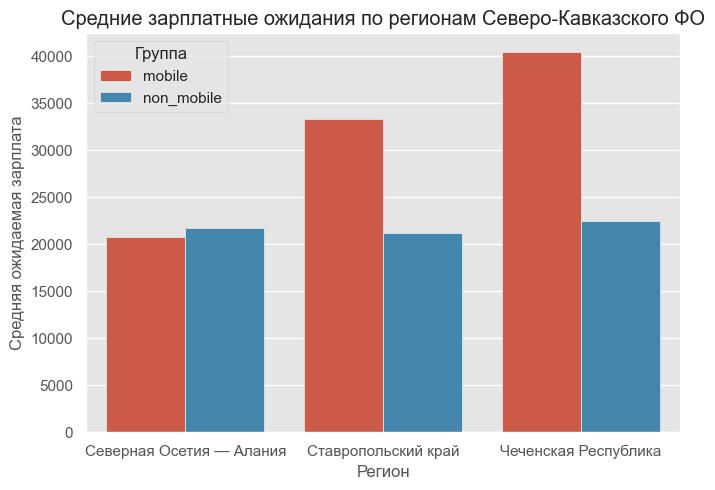

In [13]:
plot_df = results[["region_name", "mean_mobile", "mean_non_mobile"]].copy()
plot_df["mean_mobile"] = plot_df["mean_mobile"] - 880
plot_df = plot_df.melt(id_vars="region_name", value_name="mean_salary", var_name="group")
plot_df["group"] = plot_df["group"].map({"mean_mobile": "mobile", "mean_non_mobile": "non_mobile"})

plt.style.use("ggplot")
plt.figure(figsize=(7, 5))
sns.barplot(data=plot_df, x="region_name", y="mean_salary", hue="group")
plt.title("Средние зарплатные ожидания по регионам Северо-Кавказского ФО")
plt.xlabel("Регион")
plt.ylabel("Средняя ожидаемая зарплата")
plt.legend(title="Группа")
plt.tight_layout()
plt.show()

## 7. Интерпретация результатов

Интерпретация тестов:
- если `Levene p-value < 0.05`, то гипотеза о равенстве дисперсий отвергается;
- если `Welch p-value (greater) < 0.05`, то есть статистические основания считать, что мобильные соискатели в этом регионе в среднем ожидают более высокую зарплату.

По результатам расчётов:
- **Чеченская Республика**: дисперсии различаются, гипотеза о более высокой средней зарплате у мобильных подтверждается;
- **Ставропольский край**: дисперсии различаются, гипотеза о более высокой средней зарплате у мобильных подтверждается;
- **Северная Осетия — Алания**: гипотеза о равенстве дисперсий не отвергается, а гипотеза о более высокой средней зарплате у мобильных не получает статистической поддержки.

Важно: для Северной Осетии мобильная группа очень маленькая (`n=7`), поэтому вывод по этому региону менее устойчив.